In [1]:
from simulation import Simulation
from agent import Agent
import matplotlib.pyplot as plt
import random
import numpy as np

In [2]:
random.seed(1234)
np.random.seed(1234)

Let's test if each funciton actually work or not. I'll create smaller and simpler solution to test the functions out.

In [3]:
sim_test = Simulation(box_width=5, box_height=5, 
                 n_agents=10, p_susceptible=0.8, 
                 beta=1, sigma=0.1, gamma=0.005)

In [4]:
print("Number of agents:", len(sim_test.agents))

for i, agent in enumerate(sim_test.agents):
    print(f"Agent {i+1}: x={agent.x}, y={agent.y}, state={agent.state}")

Number of agents: 10
Agent 1: x=3, y=0, state=1
Agent 2: x=4, y=0, state=1
Agent 3: x=0, y=0, state=1
Agent 4: x=1, y=0, state=1
Agent 5: x=0, y=2, state=1
Agent 6: x=3, y=4, state=1
Agent 7: x=0, y=1, state=1
Agent 8: x=0, y=4, state=1
Agent 9: x=4, y=3, state=1
Agent 10: x=2, y=4, state=1


In [5]:
# Check for the fraction
sim_test.fraction_check()

'The sum of fraction is approximately 1'

In [6]:
sim_test.get_neighbour(3, 3)

[(2, 2), (2, 3), (2, 4), (3, 2), (3, 4), (4, 2), (4, 3), (4, 4)]

In [7]:
sim_test.get_neighbour(0,0) # Corner case

[(0, 1), (1, 0), (1, 1)]

In [8]:
sim_test.get_neighbour(0, 2) # Edge case

[(0, 1), (0, 3), (1, 1), (1, 2), (1, 3)]

Now, we will test if the change in state is happening correctly or not.

In [9]:
# Clear out the current agents
sim_test.agents = []

# Reminder state 1 = Susceptible / 2 = Exposed / 3 = Infected / 4 = Recovered
a1 = Agent(x=1, y=1, state=1)
a2 = Agent(x=1, y=2, state=3)
a3 = Agent(x=4, y=4, state=1)

sim_test.agents.extend([a1, a2, a3])

sim_test.grid[:, :] = 0
for agent in sim_test.agents:
    sim_test.grid[agent.y, agent.x] = agent.state

sim_test.has_infected_neighbours(a1)

True

In [10]:
sim_test.has_infected_neighbours(a3)

False

In [11]:
for i in range(3):
    print(f"Move {i+1}")
    print("Before move:", a1.x, a1.y)
    sim_test.move_agent(a1) # Randomly move the agent
    print("After move:", a1.x, a1.y)

Move 1
Before move: 1 1
After move: 1 1
Move 2
Before move: 1 1
After move: 2 2
Move 3
Before move: 2 2
After move: 3 1


In [12]:
sim_test.agents = []

a1 = Agent(1, 1, 1)   # Susceptible
a2 = Agent(4, 4, 1)   # Susceptible but far away

sim_test.agents.extend([a1, a2])

sim_test.grid[:, :] = 0
for agent in sim_test.agents:
    sim_test.grid[agent.y, agent.x] = agent.state

print("Before:", a1.state)
sim_test.update_state(a1) # Should stay susceptible 1
print("After: ", a1.state)

Before: 1
After:  1


In [13]:
sim_test.agents = []

a1 = Agent(1, 1, 1)   # Susceptible
a2 = Agent(1, 2, 3)   # Infected neighbour

sim_test.agents.extend([a1, a2])

sim_test.grid[:, :] = 0
for agent in sim_test.agents:
    sim_test.grid[agent.y, agent.x] = agent.state

print("Before:", a1.state)
sim_test.update_state(a1) # Should change to Exposed 2
print("After: ", a1.state)

Before: 1
After:  2


In [ ]:
sim_test = Simulation(box_width=5, box_height=5, 
                 n_agents=10, p_susceptible=0.8, 
                 beta=1, sigma=0.1, gamma=0.005)

print("Before MCS:")
for agent in sim_test.agents:
    print(agent.x, agent.y, agent.state)

sim_test.mcs() # 1 MCS

print("\nAfter MCS:")
for agent in sim_test.agents:
    print(agent.x, agent.y, agent.state)

Before MCS:
2 1 1
1 3 2
0 4 1
3 3 1
3 1 1
1 1 1
2 0 2
1 2 1
3 2 1
0 1 1

After MCS:
2 2 1
1 3 2
0 4 1
3 3 1
4 1 1
1 1 1
3 0 2
2 3 1
4 3 1
0 0 1


All the functions seem to work. We will try and run the simulation now. Starts with the example given by the brief.

In [15]:
sim_ex = Simulation(box_width=100, box_height=100, 
                 n_agents=250, p_susceptible=0.95, 
                 beta=1, sigma=0.1, gamma=0.005)

In [16]:
print(sim_ex.count_states())
print(sim_ex.fraction_check())

(239, 11, 0, 0)
The sum of fraction is approximately 1


In [17]:
sim_ex.run_simulation(n_steps=2000, snapshot_steps=[0, 500, 1000, 2000])

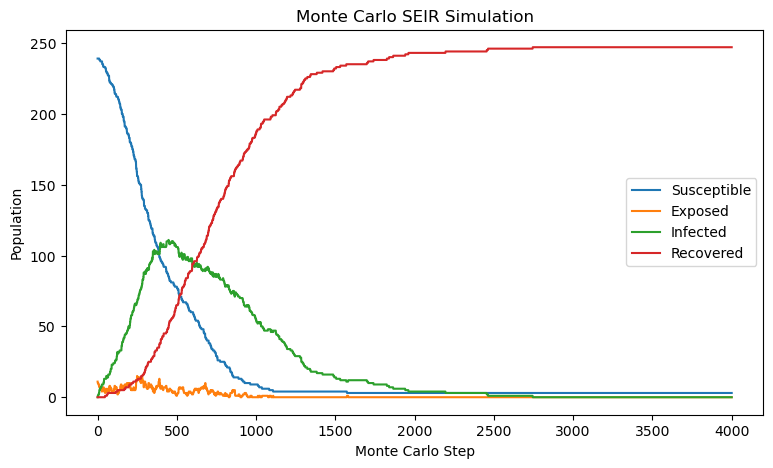

In [18]:
sim_ex.plot_history()

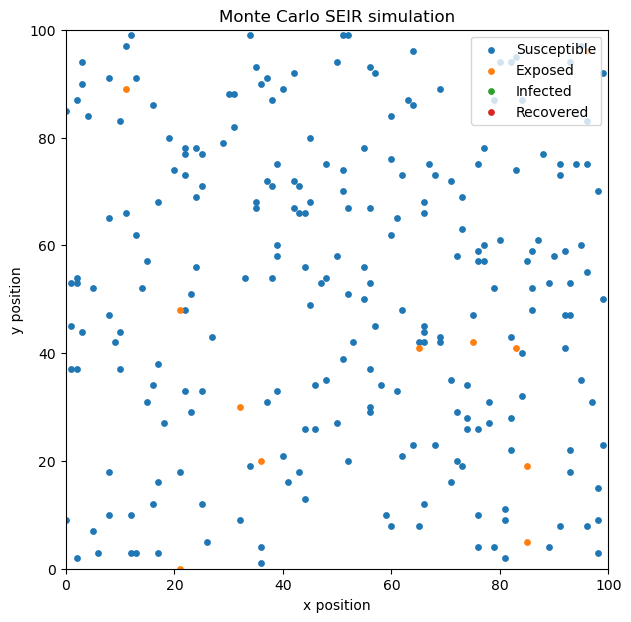

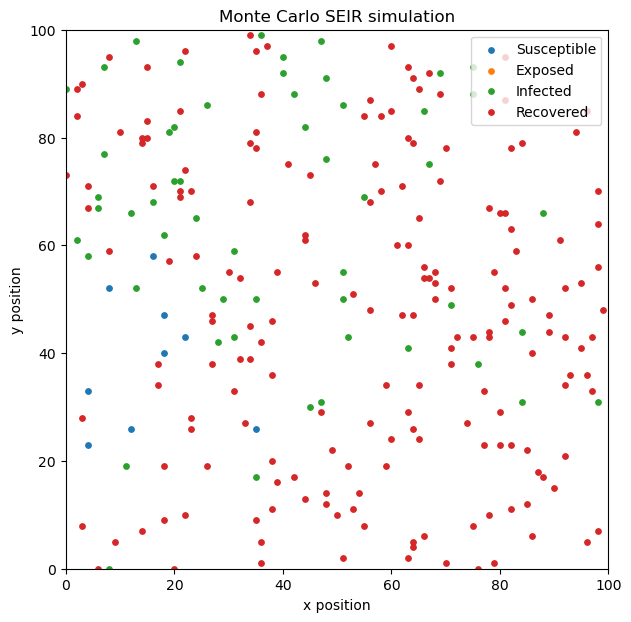

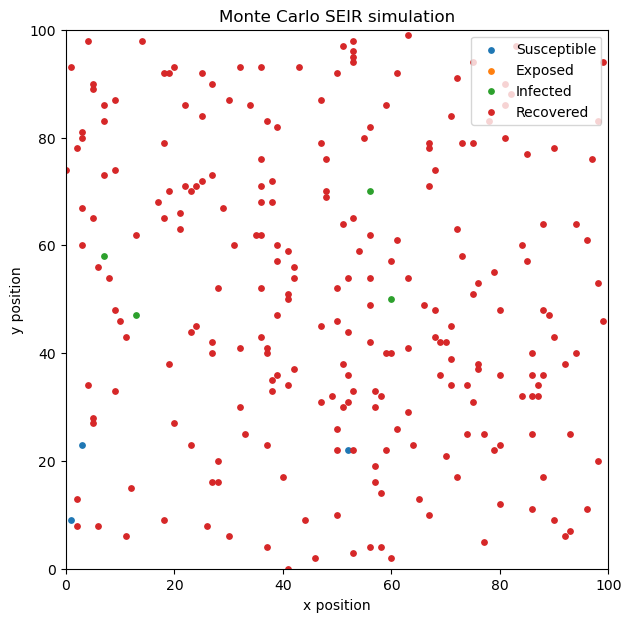

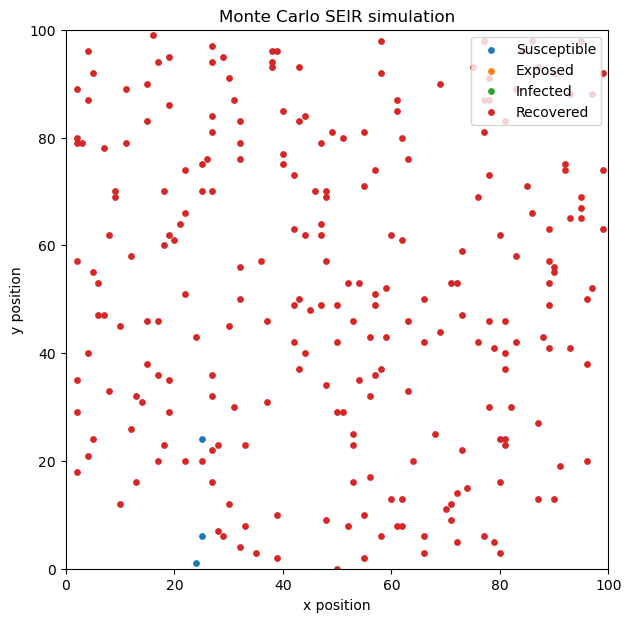

In [19]:
sim_ex.plot_lattice(0)
sim_ex.plot_lattice(500)
sim_ex.plot_lattice(1000)
sim_ex.plot_lattice(2000)

Things seem to work just fine. I will now start exploring by varying the parameters and find conditions for which an outbreak occurs and for which it dies away. Let's first start with changing the density of agents. I will increase n_agents.

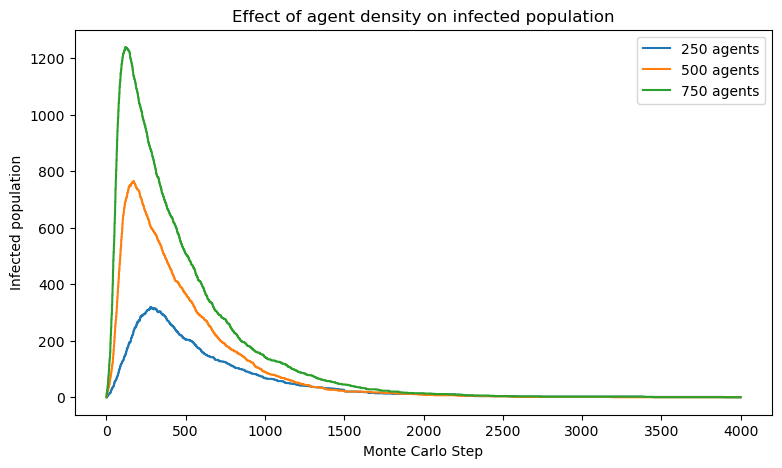

In [20]:
density_cases = [250, 500, 750]
density_results = {}

for n_agents in density_cases:
    sim = Simulation(box_width=100, box_height=100,
                     n_agents=n_agents, p_susceptible=0.95,
                     beta=1, sigma=0.1, gamma=0.005)
    
    sim.initialise_agents()
    sim.run_simulation(n_steps=2000)
    
    density_results[n_agents] = {"s": sim.s_history,
                                 "e": sim.e_history,
                                 "i": sim.i_history,
                                 "r": sim.r_history}

plt.figure(figsize=(9, 5))

for n_agents in density_cases:
    plt.plot(density_results[n_agents]["i"], label=f"{n_agents} agents")

plt.xlabel("Monte Carlo Step")
plt.ylabel("Infected population")
plt.title("Effect of agent density on infected population")
plt.legend()
plt.show()

Now for different gamma values (the recovery rate)

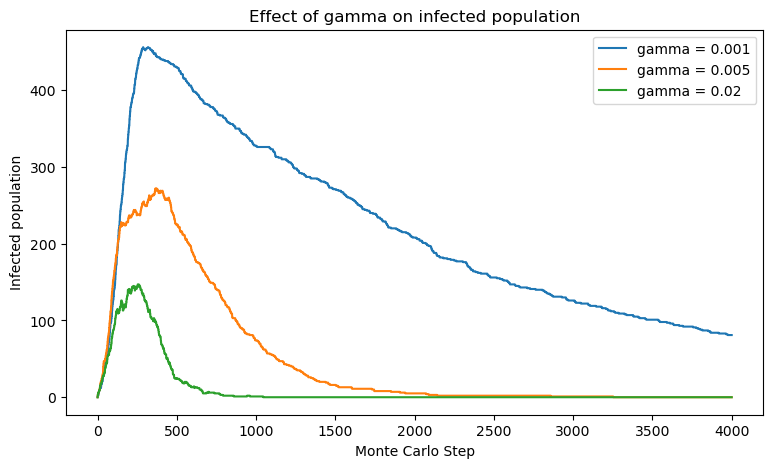

In [21]:
gamma_cases = [0.001, 0.005, 0.02]
gamma_results = {}

for gamma in gamma_cases:
    sim = Simulation(box_width=100, box_height=100,
                     n_agents=250, p_susceptible=0.95,
                     beta=1, sigma=0.1, gamma=gamma)
    
    sim.initialise_agents()
    sim.run_simulation(n_steps=2000)
    
    gamma_results[gamma] = sim.i_history

plt.figure(figsize=(9, 5))

for gamma in gamma_cases:
    plt.plot(gamma_results[gamma], label=f"gamma = {gamma}")

plt.xlabel("Monte Carlo Step")
plt.ylabel("Infected population")
plt.title("Effect of gamma on infected population")
plt.legend()
plt.show()

Now for the incubation rate sigma

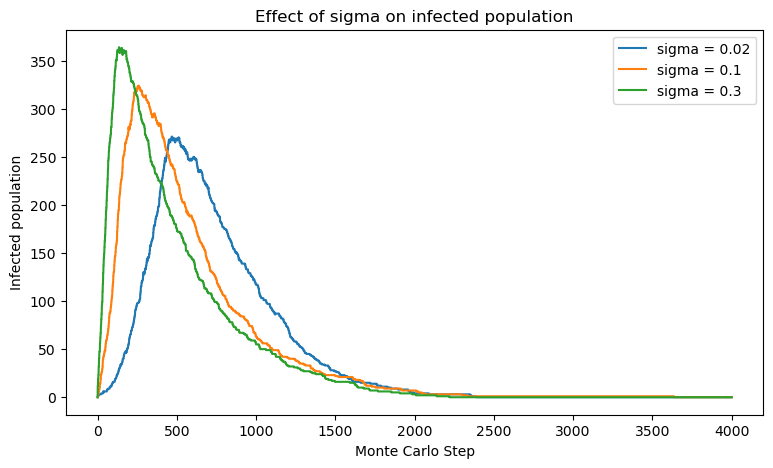

In [22]:
sigma_cases = [0.02, 0.1, 0.3]
sigma_results = {}

for sigma in sigma_cases:
    sim = Simulation(box_width=100, box_height=100,
                     n_agents=250, p_susceptible=0.95,
                     beta=1, sigma=sigma, gamma=0.005)
    
    sim.initialise_agents()
    sim.run_simulation(n_steps=2000)
    
    sigma_results[sigma] = sim.i_history

plt.figure(figsize=(9, 5))

for sigma in sigma_cases:
    plt.plot(sigma_results[sigma], label=f"sigma = {sigma}")

plt.xlabel("Monte Carlo Step")
plt.ylabel("Infected population")
plt.title("Effect of sigma on infected population")
plt.legend()
plt.show()